# Human Gesture Recognition (HGR) using IMU Sensor Data
**Time Series Implementation**

## 1. Environment Setup & Imports
Importing the necessary libraries for data manipulation, signal processing, visualization, and database connectivity. Custom helper functions from `utils.py` and `utils_visual.py` are also loaded.

In [65]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [66]:
time_start = time()

## 2. Data Loading & Initial Cleaning
In this section, we connect to the local MongoDB instance and retrieve the continuous recording sessions. 
We also perform an initial sanity check for missing values (`NaN`) and handle instances where the hardware sensor arrays might have recorded unequal lengths.

In [67]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [68]:
client = pymongo.MongoClient(config["client"])

In [69]:
db = client[config["db"]]
coll = db[config["col"]]

In [70]:
found_keys = coll.distinct("label")
print("Existing DB keys:", found_keys)

Existing DB keys: []


In [71]:
# Fetch all records from the collection
cursor = coll.find({})
data_list = list(cursor)

# Load into DataFrame and drop the MongoDB '_id'
df = pd.DataFrame(data_list)
if not df.empty:
    df = df.drop(columns=['_id'])
    print(f"Successfully loaded {len(df)} total instances across all subjects.")
else:
    print("No data found.")


Successfully loaded 41 total instances across all subjects.


## Explore the nature of the data

In [72]:
# Calculate the number of samples for each instance 
# We take the length of the first list inside the 'data' dictionary
df['num_samples'] = df['data'].apply(lambda x: len(next(iter(x.values()))))

# Calculate time length in seconds (samples / sampling rate)
df['time_length_sec'] = df['num_samples'] / df['sr']

# Calculate time length in minutes for easier reading
df['time_length_min'] = df['time_length_sec'] / 60

# Preview the new columns
df[['gesture_id', 'num_samples', 'time_length_sec', 'time_length_min']].head()

,gesture_id,num_samples,time_length_sec,time_length_min
0,scroll-down-thumb,9069,90.69,1.511500
1,scroll-down-thumb,9028,90.28,1.504667
2,scroll-down-thumb,6076,60.76,1.012667
3,scroll-down-thumb,4300,43.00,0.716667
4,scroll-down-thumb,6972,69.72,1.162000


In [73]:
# Group by gesture class and sum the total time length
time_per_class = df.groupby('gesture_id')['time_length_min'].sum().reset_index()
time_per_class = time_per_class.rename(columns={'time_length_min': 'total_time_min'})

# Display the aggregated data
print(time_per_class)

           gesture_id  total_time_min
0   scroll-down-thumb       14.803667
1   scroll-left-thumb       14.439500
2  scroll-right-thumb       13.953000
3     scroll-up-thumb       14.219667
4       texting-thumb       14.490000


C:\Users\smant\AppData\Local\Temp\ipykernel_8536\840942408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_per_class, x='gesture_id', y='total_time_min', palette='viridis')


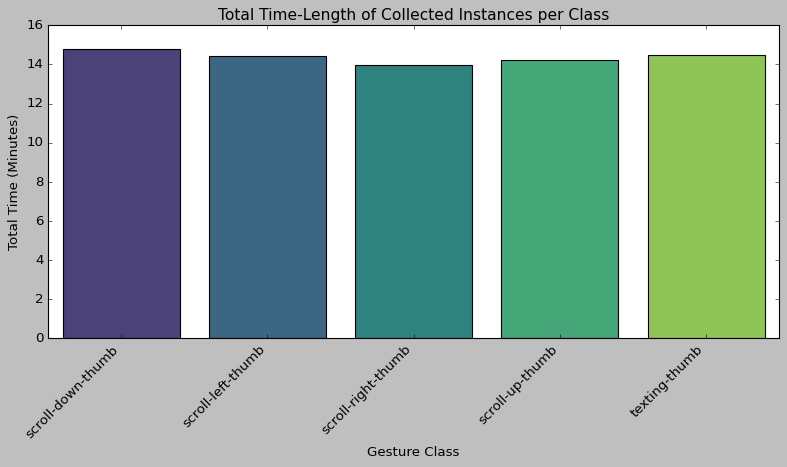

In [74]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create the barplot
sns.barplot(data=time_per_class, x='gesture_id', y='total_time_min', palette='viridis')

# Add titles and labels
plt.title('Total Time-Length of Collected Instances per Class', fontsize=14)
plt.xlabel('Gesture Class', fontsize=12)
plt.ylabel('Total Time (Minutes)', fontsize=12)

# Rotate the x-axis labels if they are long
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

In [75]:
# Check for missing values in the raw dataset before segmentation
print("Checking for missing values and unequal lengths in the raw continuous data...")
missing_found = False

for index, row in df.iterrows():
    # Convert each array to a pandas Series first. 
    # This forces Pandas to accept unequal lengths by padding the shorter ones with NaNs.
    instance_df = pd.DataFrame({k: pd.Series(v) for k, v in row['data'].items()})
    
    if instance_df.isnull().values.any():
        #print(f"Missing values or unequal lengths found in row {index} (Gesture: {row['gesture_id']}) - Fixing automatically!")
        missing_found = True
        
        # FIXING THE DATA:
        # 1. Interpolate (draw a line) to fill any internal missing packets
        instance_df = instance_df.interpolate(method='linear')
        
        # 2. Drop any remaining NaNs at the very end (truncates all arrays to the length of the shortest one)
        instance_df = instance_df.dropna()
        
        # 3. Save the cleaned data back into our main DataFrame
        df.at[index, 'data'] = instance_df.to_dict('list')

if missing_found:
    print("All missing values and unequal lengths have been successfully cleaned!")
else:
    print("No missing values found in the raw data!")

Checking for missing values and unequal lengths in the raw continuous data...
All missing values and unequal lengths have been successfully cleaned!


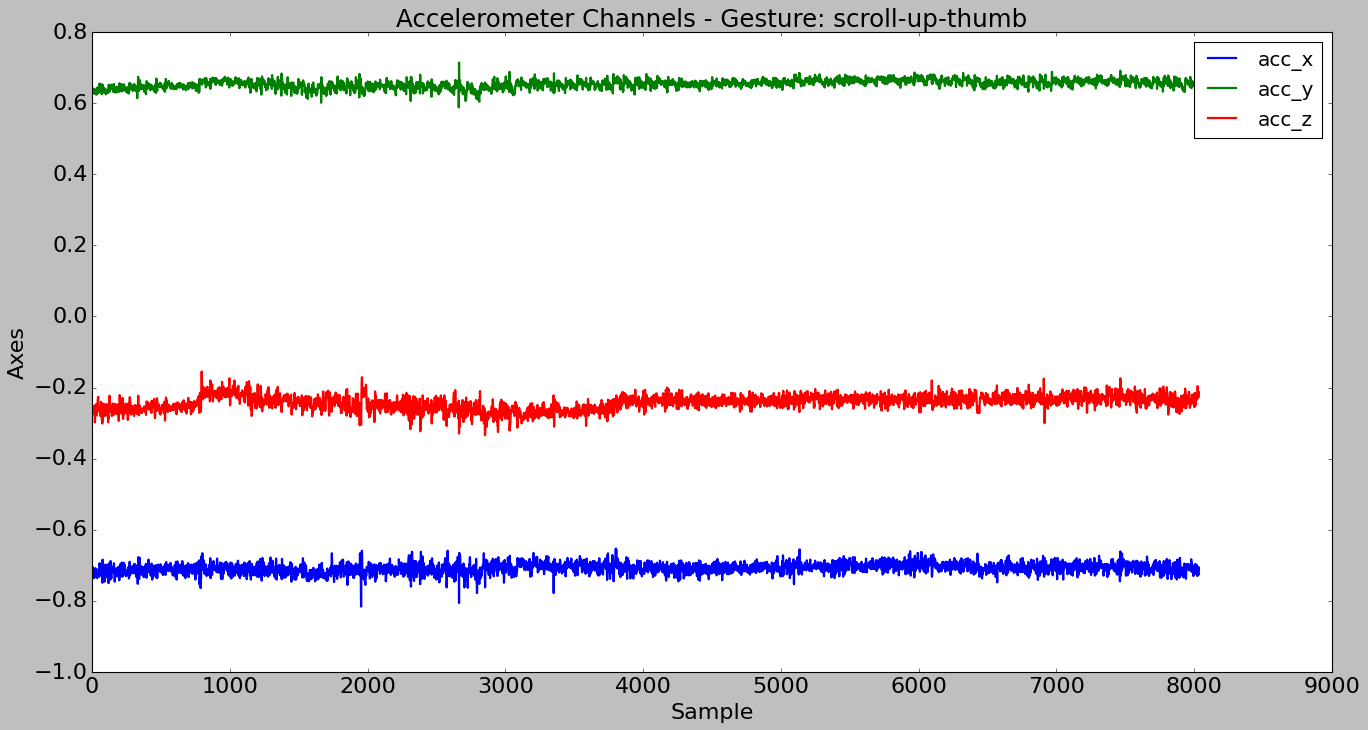

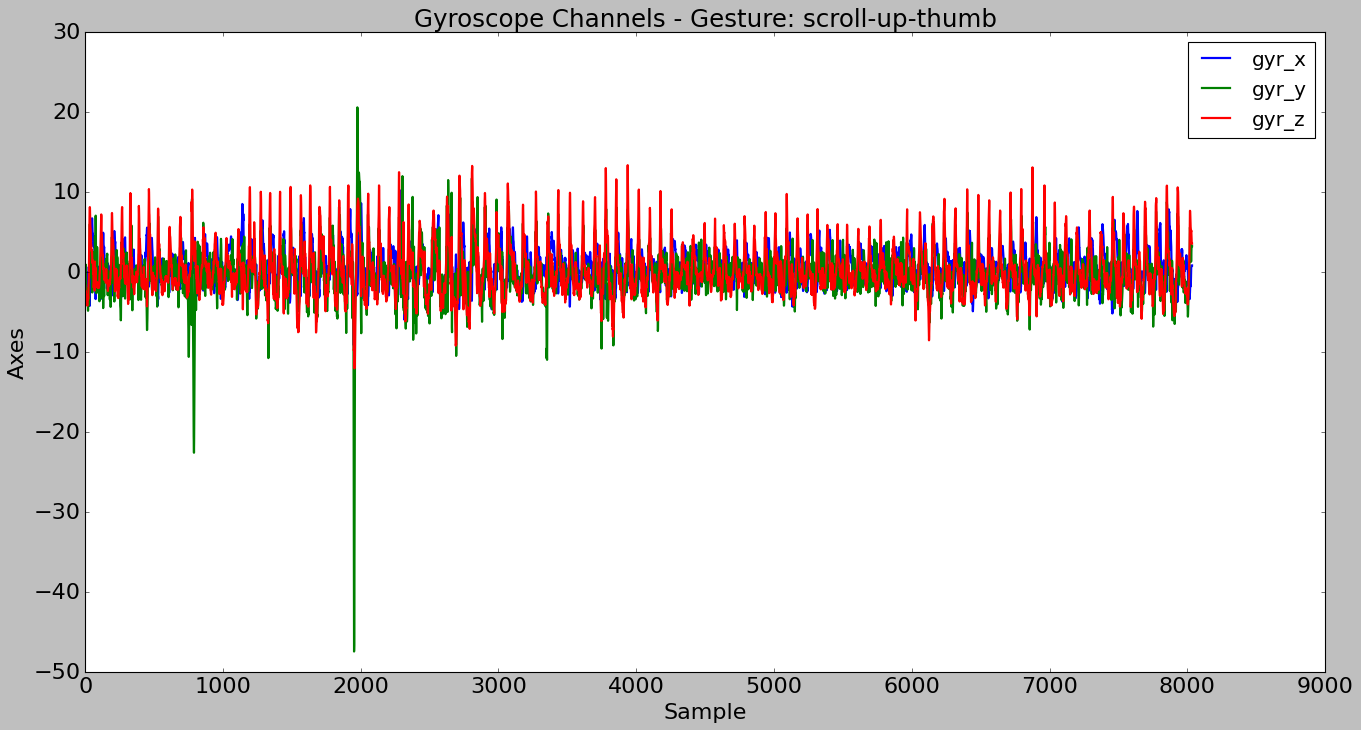

In [76]:
def plot_instance_time_domain(df: pd.DataFrame):
    """Visualizes the movement instance to a plot in time domain.

    Args:
        df: The DataFrame to be visualized in time domain.

    Returns:

    """
    df.plot(figsize=(20, 10), linewidth=2, fontsize=20).legend(fontsize=18)
    plt.xlabel('Sample', fontsize=20)
    plt.ylabel('Axes', fontsize=20)


# 1. Extract a continuous instance from the dataframe (e.g., the first recording)
sample_idx = 30
instance_df = pd.DataFrame(df.iloc[sample_idx]['data'])
gesture_id = df.iloc[sample_idx]['gesture_id'] # Get the gesture ID for the title

# 2. Separate accelerometer and gyroscope columns
acc_cols = [col for col in instance_df.columns if 'acc' in col.lower()]
gyr_cols = [col for col in instance_df.columns if 'gyr' in col.lower()]

# Fallback in case columns aren't explicitly named 'acc'/'gyr'
if not acc_cols:
    acc_cols = instance_df.columns[:3] 
if not gyr_cols:
    gyr_cols = instance_df.columns[3:6] 

# 3. Plot Accelerometer channels (Subplot 1)
plot_instance_time_domain(instance_df[acc_cols])
plt.title(f'Accelerometer Channels - Gesture: {gesture_id}', fontsize=22)
plt.show()

# 4. Plot Gyroscope channels (Subplot 2)
plot_instance_time_domain(instance_df[gyr_cols])
plt.title(f'Gyroscope Channels - Gesture: {gesture_id}', fontsize=22)
plt.show()

## 3. Signal Processing: Low-Pass Filtering
Raw IMU sensor data often contains high-frequency noise caused by hardware vibrations or natural human hand tremors. Since the core physical movements of gestures (like swiping or scrolling) occur at lower frequencies, we apply a **Low-Pass Filter** to smooth the signal and isolate the true gesture trajectory.

In [77]:
from utils import apply_filter

print("Applying lowpass filter to the dataset using utils.py...")

# Extract filter parameters from your config.yml
filter_order = config['filter']['order']
cutoff_freq = config['filter']['wn'] 
filter_type = config['filter']['type']

def filter_session_data(instance_data, sr):
    """
    Wrapper to apply utils.apply_filter to the dictionary of axes,
    handling the Nyquist frequency normalization.
    """
    filtered_data = {}
    
    # 1. Calculate the Nyquist frequency (half of the sampling rate)
    nyquist_freq = 0.5 * sr
    
    # 2. Normalize the cutoff frequency to be between 0 and 1
    normalized_wn = cutoff_freq / nyquist_freq 
    
    for axis_name, values in instance_data.items():
        # 3. Call your existing apply_filter function
        filtered_array = apply_filter(
            arr=values, 
            order=filter_order, 
            wn=normalized_wn,  # MUST use the normalized frequency here
            filter_type=filter_type
        )
        filtered_data[axis_name] = filtered_array.tolist()
        
    return filtered_data

# Apply the filter row by row, respecting the 'sr' of each session
df['filtered_data'] = df.apply(
    lambda row: filter_session_data(row['data'], row['sr']), 
    axis=1
)

print("Filtering complete!")

# Preview the results to verify
df[['gesture_id', 'sr', 'data', 'filtered_data']].head(3)

Applying lowpass filter to the dataset using utils.py...
Filtering complete!


,gesture_id,sr,data,filtered_data
0,scroll-down-thumb,100,"{'acc_x': [-0.737, -0.753, -0.759, -0.769, -0....","{'acc_x': [-0.7469726236123487, -0.75296605271..."
1,scroll-down-thumb,100,"{'acc_x': [-0.902, -0.924, -0.94, -0.945, -0.9...","{'acc_x': [-0.9163219976691075, -0.92343820098..."
2,scroll-down-thumb,100,"{'acc_x': [-1.006, -1.004, -0.994, -0.997, -1....","{'acc_x': [-1.0027714862968207, -1.00163359923..."


Plotting RAW data for gesture: scroll-down-thumb (First 300 samples)


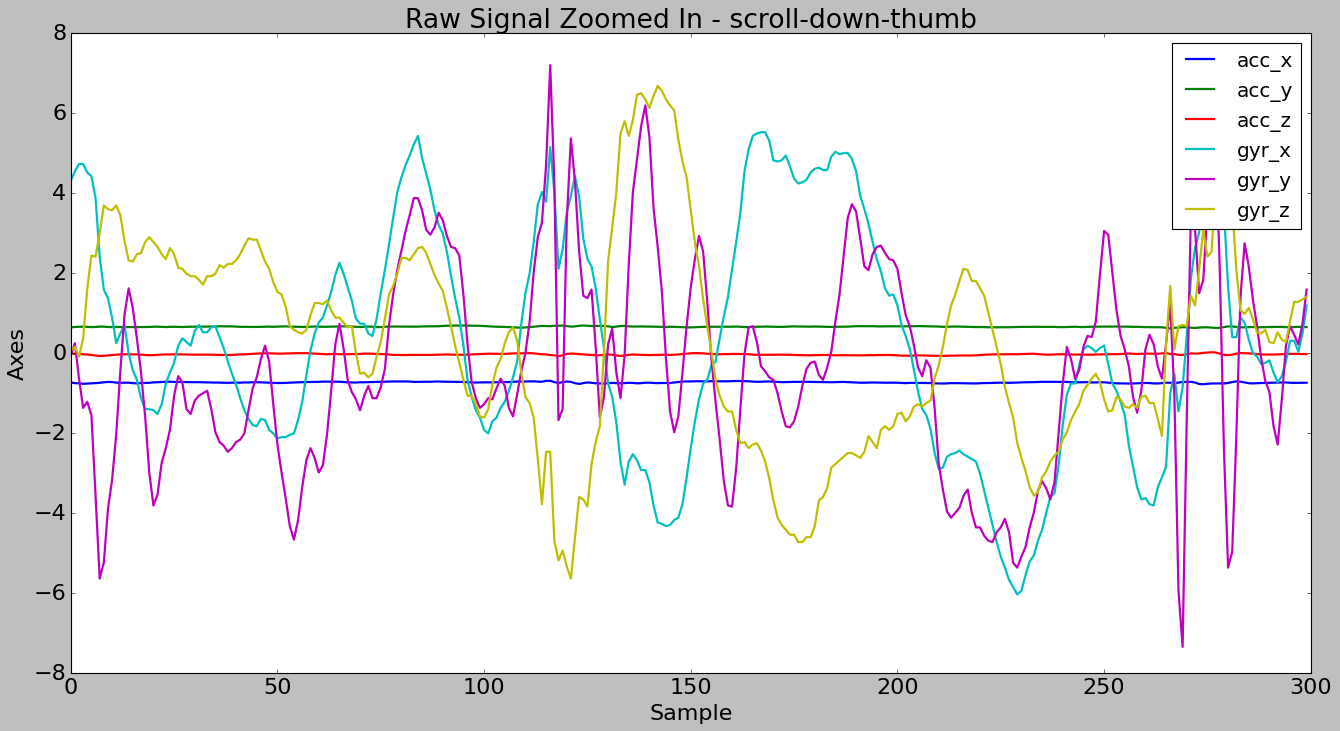

Plotting FILTERED data for gesture: scroll-down-thumb (First 300 samples)


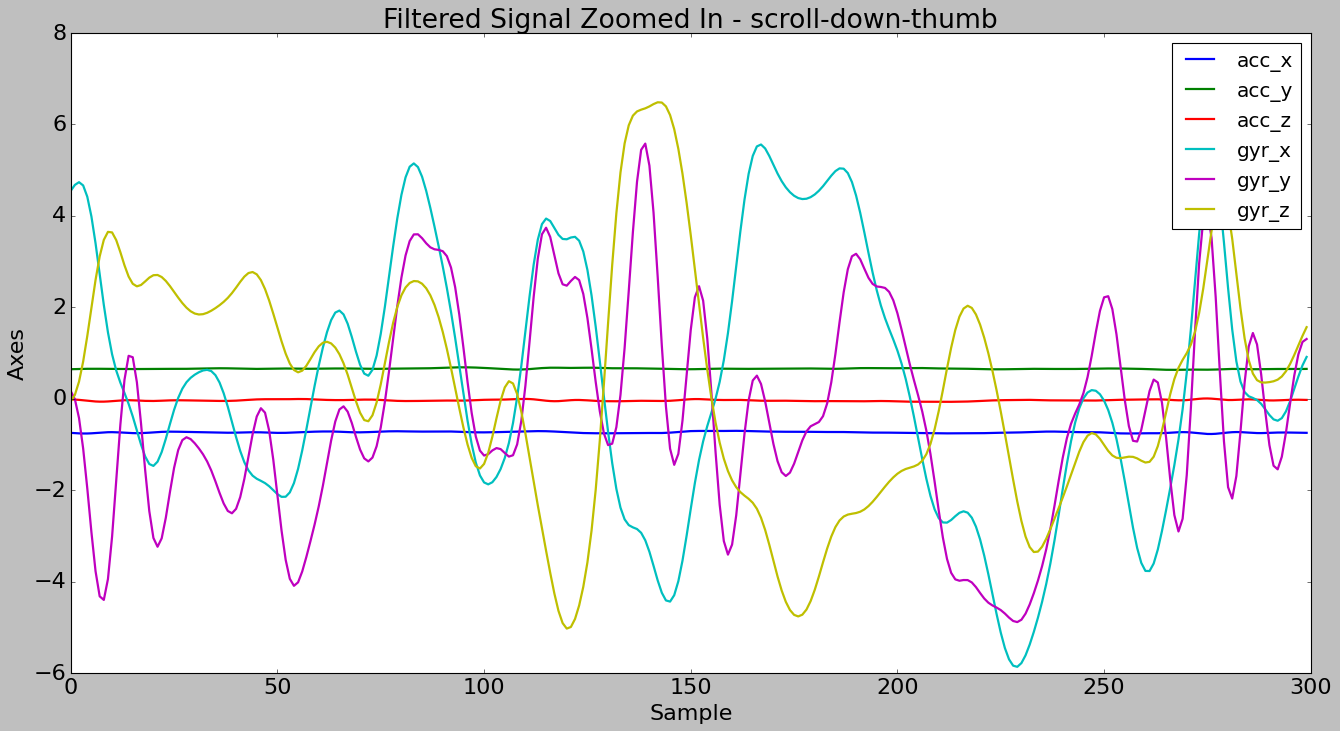

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
from utils_visual import plot_instance_time_domain

# 1. Select a single instance (index 0)
sample_idx = 0
raw_data_dict = df.iloc[sample_idx]['data']
filtered_data_dict = df.iloc[sample_idx]['filtered_data']
gesture_label = df.iloc[sample_idx]['gesture_id']

# 2. Convert both data dictionaries into Pandas DataFrames
df_raw = pd.DataFrame(raw_data_dict)
df_filtered = pd.DataFrame(filtered_data_dict)

# 3. Slice the data to view only a specific time frame (e.g., first 300 samples)
zoom_samples = 300 
df_raw_zoomed = df_raw.iloc[:zoom_samples]
df_filtered_zoomed = df_filtered.iloc[:zoom_samples]

# 4. Plot the RAW data
print(f"Plotting RAW data for gesture: {gesture_label} (First {zoom_samples} samples)")
plot_instance_time_domain(df_raw_zoomed)
plt.title(f"Raw Signal Zoomed In - {gesture_label}", fontsize=24)
plt.show()

# 5. Plot the FILTERED data
print(f"Plotting FILTERED data for gesture: {gesture_label} (First {zoom_samples} samples)")
plot_instance_time_domain(df_filtered_zoomed)
plt.title(f"Filtered Signal Zoomed In - {gesture_label}", fontsize=24)
plt.show()

## 4. Exploratory Data Analysis (Pre-Segmentation)
Before segmenting the continuous data, we visualize the raw signals to understand the physical biomechanics of the gestures.

### 4.1. 3D Spatial Trajectories & Subject Variance
The 3D scatter plots below trace the path of the hand through physical space. By overlaying all sessions and color-coding by subject, we can visualize **intra-class variance** (how a single user's gestures fluctuate over time) and **inter-subject variance** (how different people perform the exact same gesture).


GESTURE: SCROLL-DOWN-THUMB


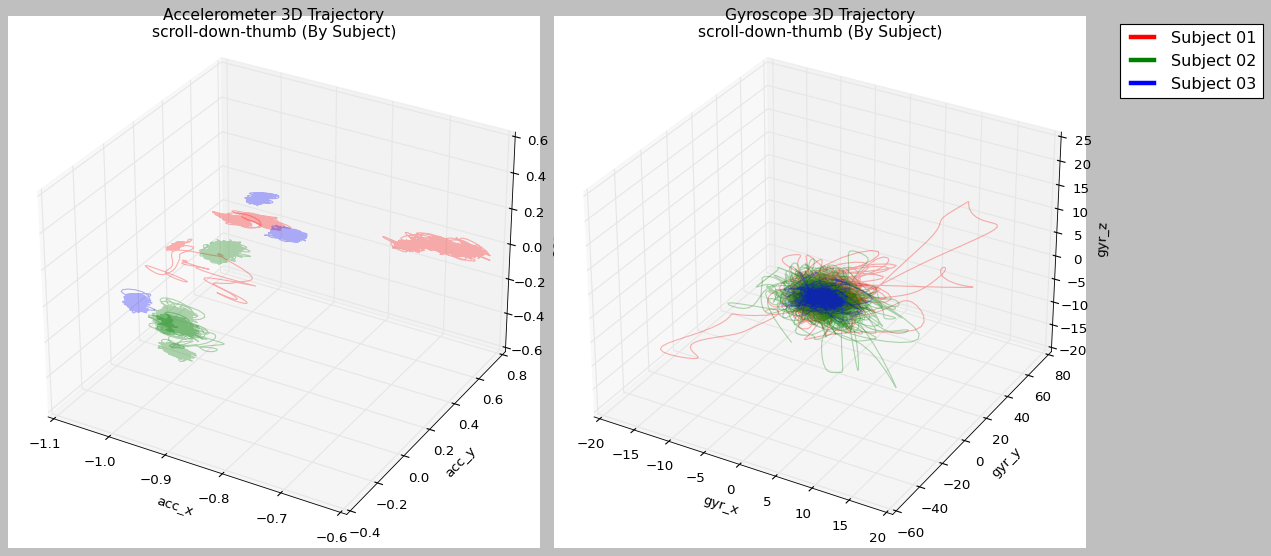


GESTURE: SCROLL-LEFT-THUMB


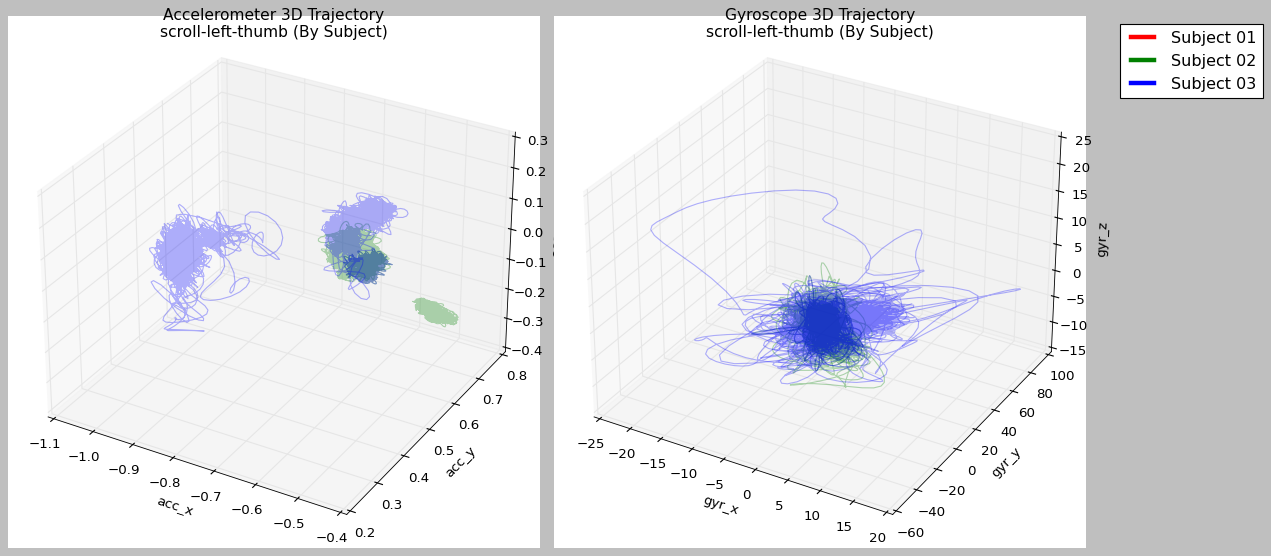


GESTURE: SCROLL-RIGHT-THUMB


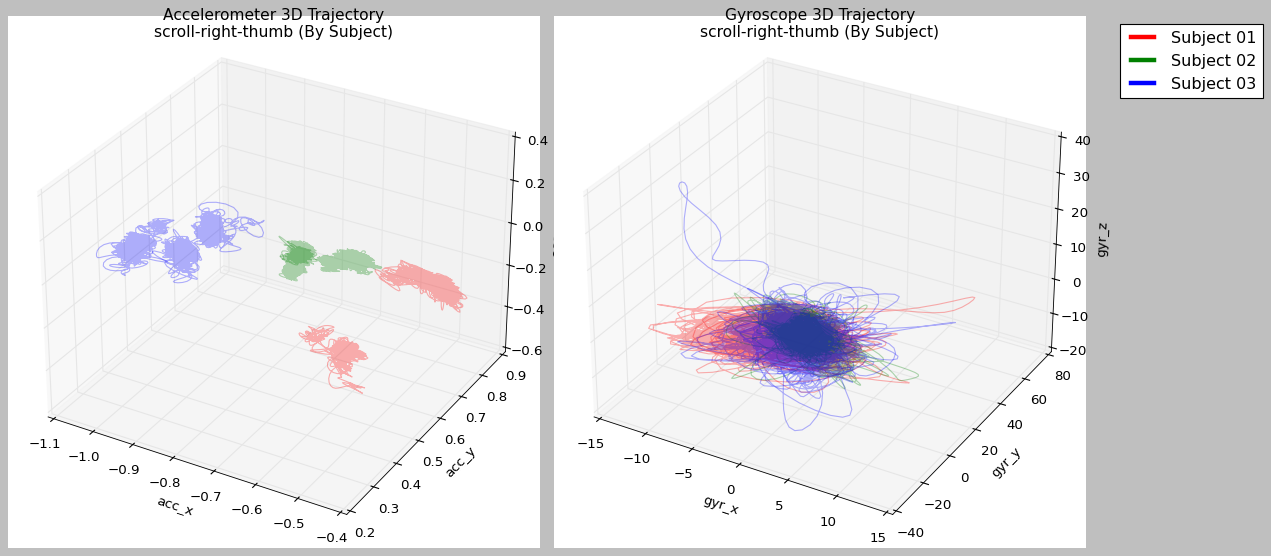


GESTURE: SCROLL-UP-THUMB


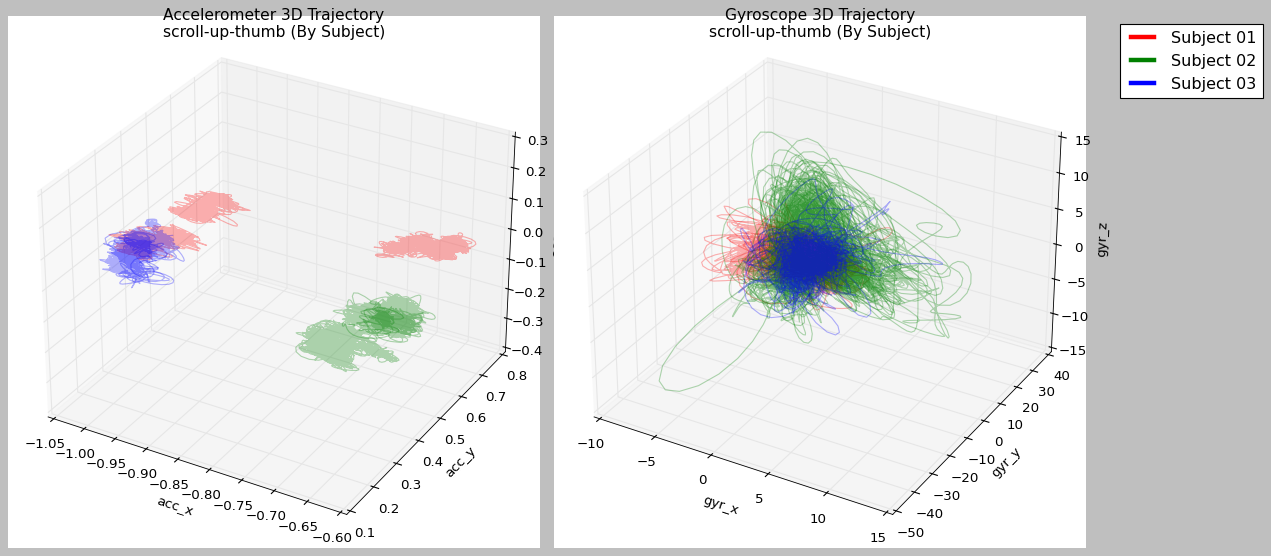


GESTURE: TEXTING-THUMB


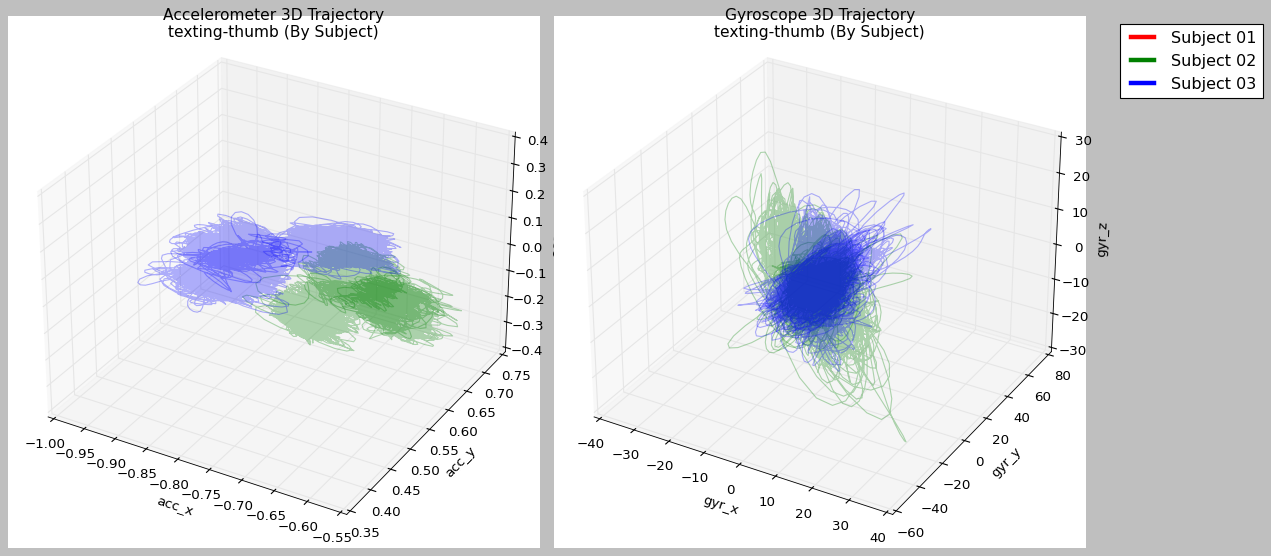

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- CONFIGURATION ---
GESTURE_COL = 'gesture_id' 
DATA_COL = 'filtered_data' 
SUBJECT_COL = 'user'  
# ---------------------

# Get lists of unique gestures and unique subjects
unique_gestures = df[GESTURE_COL].unique()
unique_subjects = df[SUBJECT_COL].unique()

# --- NEW: Strict RGB Palette for 3 Subjects ---
rgb_colors = ['red', 'green', 'blue']

# Assign a specific RGB color to each unique subject safely
subject_colors = {}
for i, subject in enumerate(unique_subjects):
    # Use modulo (%) to wrap around safely
    subject_colors[subject] = rgb_colors[i % len(rgb_colors)]

for gesture in unique_gestures:
    print(f"\n{'='*60}")
    print(f"GESTURE: {str(gesture).upper()}")
    print(f"{'='*60}")
    
    # 1. Get all rows for this specific gesture
    gesture_rows = df[df[GESTURE_COL] == gesture]
    
    # 2. Create a figure with two 3D subplots side-by-side
    fig = plt.figure(figsize=(16, 8))
    
    # --- Setup Accelerometer Subplot (Left) ---
    ax_acc = fig.add_subplot(121, projection='3d')
    ax_acc.set_title(f"Accelerometer 3D Trajectory\n{gesture} (By Subject)", pad=20, fontsize=14)
    ax_acc.set_xlabel("acc_x")
    ax_acc.set_ylabel("acc_y")
    ax_acc.set_zlabel("acc_z")
    
    # --- Setup Gyroscope Subplot (Right) ---
    ax_gyr = fig.add_subplot(122, projection='3d')
    ax_gyr.set_title(f"Gyroscope 3D Trajectory\n{gesture} (By Subject)", pad=20, fontsize=14)
    ax_gyr.set_xlabel("gyr_x")
    ax_gyr.set_ylabel("gyr_y")
    ax_gyr.set_zlabel("gyr_z")
    
    # 3. Loop through EVERY session
    for _, row in gesture_rows.iterrows():
        session_data_dict = row[DATA_COL]
        subject_id = row[SUBJECT_COL]  
        
        # Look up the designated color for this subject
        color = subject_colors[subject_id]
        
        # Convert dictionary to DataFrame
        instance_df = pd.DataFrame({k: pd.Series(v) for k, v in session_data_dict.items()})
        
        # Plot trajectories using the SUBJECT'S custom RGB color
        ax_acc.plot(instance_df["acc_x"], instance_df["acc_y"], instance_df["acc_z"], color=color, alpha=0.3)
        ax_gyr.plot(instance_df["gyr_x"], instance_df["gyr_y"], instance_df["gyr_z"], color=color, alpha=0.3)

    # 4. Create a custom legend
    legend_elements = [Line2D([0], [0], color=color, lw=4, label=f'Subject {sub}') 
                       for sub, color in subject_colors.items()]
    
    # Add the legend to the right side of the figure
    ax_gyr.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))
        
    # Adjust layout and display
    plt.tight_layout()
    plt.show()

### 4.2. Global Sensor Correlation Analysis
By concatenating all sessions across all gestures into a single dataset, we compute a global correlation matrix. Strong correlations (positive or negative) reveal universal physical constraints, such as the natural rotational mechanics of the wrist or the constant downward pull of Earth's gravity on the Z-axis.

Concatenating all sessions across all gestures. This might take a moment...


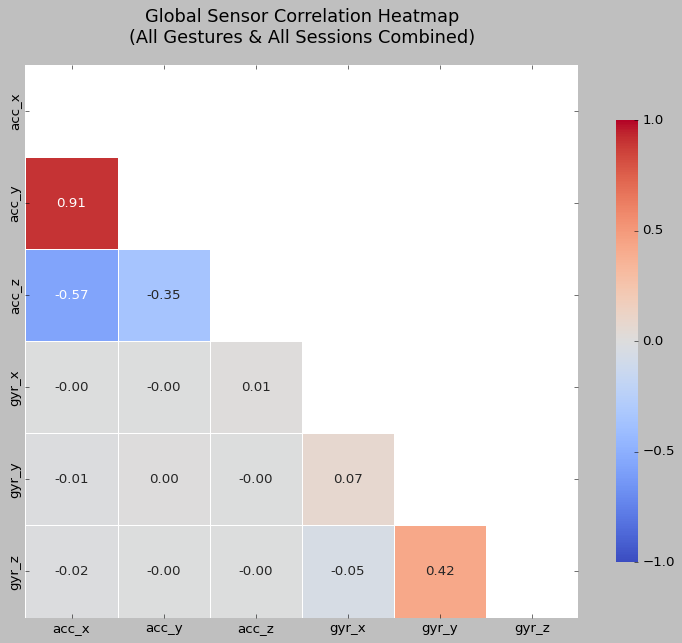

Total data points analyzed: 431435


In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DATA_COL = 'filtered_data' 
# ---------------------

print("Concatenating all sessions across all gestures. This might take a moment...")

# List to hold the DataFrame of every single session in the dataset
all_sessions_dfs = []

# 1. Loop through EVERY row in the entire dataframe
for _, row in df.iterrows():
    session_data_dict = row[DATA_COL]
    
    # Convert the dictionary to a DataFrame, safely handling unequal array lengths
    instance_df = pd.DataFrame({k: pd.Series(v) for k, v in session_data_dict.items()})
    
    all_sessions_dfs.append(instance_df)
    
# 2. Concatenate all sessions into one massive continuous DataFrame
global_df = pd.concat(all_sessions_dfs, ignore_index=True)

# 3. Calculate the Pearson correlation matrix for the entire dataset
global_corr_matrix = global_df.corr()

# 4. Create a mask for the upper triangle
# np.ones_like creates a matrix of True values the same shape as our correlation matrix
# np.triu isolates just the upper triangle of that matrix
mask = np.triu(np.ones_like(global_corr_matrix, dtype=bool))

# 5. Plot the Global Heatmap
plt.figure(figsize=(10, 8))

# Add the 'mask=mask' argument to hide the upper triangle
sns.heatmap(global_corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={"shrink": .8})

plt.title("Global Sensor Correlation Heatmap\n(All Gestures & All Sessions Combined)", pad=20, fontsize=16)

# Adjust layout and display
plt.tight_layout()
plt.show()

print(f"Total data points analyzed: {len(global_df)}")

### 4.3. Feature Variance & Distribution Profiling
To understand the dynamic range of our sensors, we utilize box plots. This explicitly shows the massive scale difference between the Accelerometer (measuring linear g-force, ~[-5, 5]) and the Gyroscope (measuring angular velocity, ~[-500, 500]), justifying the strict necessity for feature scaling later in the pipeline.

Concatenating all sessions across all gestures. This might take a moment...


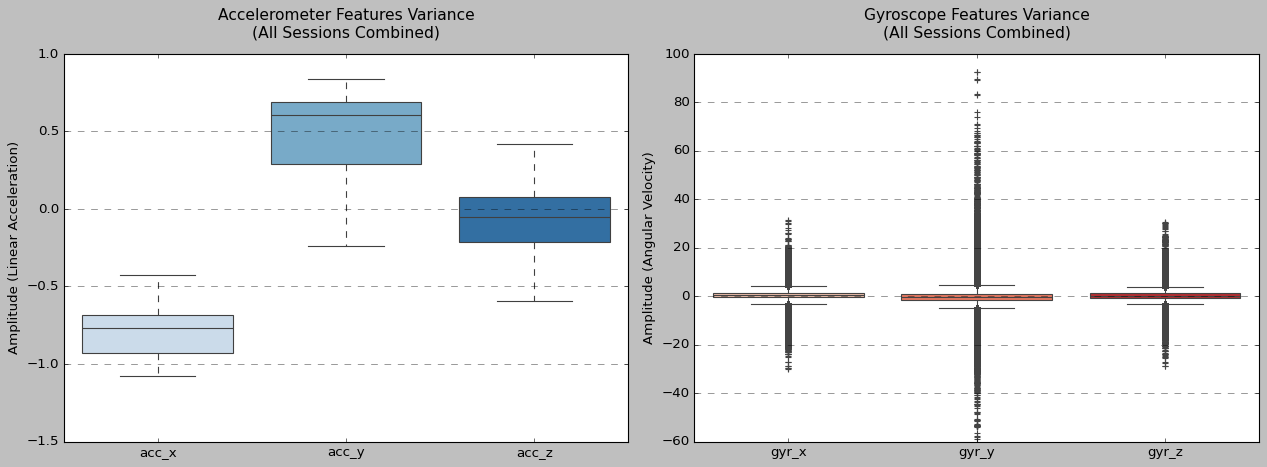

Total data points visualized: 431435


In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DATA_COL = 'filtered_data' 
# ---------------------

print("Concatenating all sessions across all gestures. This might take a moment...")

# List to hold the DataFrame of every single session in the dataset
all_sessions_dfs = []

# 1. Loop through EVERY row in the entire dataframe
for _, row in df.iterrows():
    session_data_dict = row[DATA_COL]
    
    # Convert the dictionary to a DataFrame, safely handling unequal array lengths
    instance_df = pd.DataFrame({k: pd.Series(v) for k, v in session_data_dict.items()})
    
    all_sessions_dfs.append(instance_df)
    
# 2. Concatenate all sessions into one massive continuous DataFrame
global_df = pd.concat(all_sessions_dfs, ignore_index=True)

# 3. Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Setup Accelerometer Boxplot (Left) ---
# We isolate only the accelerometer columns so they scale correctly
sns.boxplot(data=global_df[['acc_x', 'acc_y', 'acc_z']], ax=axes[0], palette="Blues")
axes[0].set_title("Accelerometer Features Variance\n(All Sessions Combined)", pad=15, fontsize=14)
axes[0].set_ylabel("Amplitude (Linear Acceleration)")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Setup Gyroscope Boxplot (Right) ---
# We isolate only the gyroscope columns so they scale correctly
sns.boxplot(data=global_df[['gyr_x', 'gyr_y', 'gyr_z']], ax=axes[1], palette="Reds")
axes[1].set_title("Gyroscope Features Variance\n(All Sessions Combined)", pad=15, fontsize=14)
axes[1].set_ylabel("Amplitude (Angular Velocity)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

print(f"Total data points visualized: {len(global_df)}")

## 5. Window Segmentation
Machine learning models require fixed-size inputs. We apply a **Sliding Window** technique to chop the long, continuous recordings into discrete matrices (windows). The sliding window utilizes a predefined size and overlap parameter, creating natural data augmentation by capturing the gestures at various starting phases.

In [82]:
import pandas as pd
from utils import sliding_window_pd

print("Starting sliding window segmentation...")

# 1. Extract parameters from your config.yml
ws = config['sliding_window']['ws']
overlap = config['sliding_window']['overlap']
w_type = config['sliding_window']['w_type']
w_center = config['sliding_window']['w_center']

# Initialize our unified lists
all_windows = [] # This will hold our X (list of Window DataFrames)
all_labels = []  # This will hold our y (list of target gesture_ids)

# 2. Iterate over each recording session independently
for index, row in df.iterrows():
    gesture_label = row['gesture_id']
    filtered_data_dict = row['filtered_data']
    
    # Convert the filtered dictionary back into a Pandas DataFrame
    session_df = pd.DataFrame(filtered_data_dict)
    
    # 3. Apply your existing sliding window function
    # This returns a list of small DataFrames (the windows) for this specific session
    session_windows = sliding_window_pd(
        df=session_df,
        ws=ws,
        overlap=overlap,
        w_type=w_type,
        w_center=w_center,
        print_stats=False # Keep it False so it doesn't flood your Jupyter output
    )
    
    # 4. Add these new windows to our unified master list
    all_windows.extend(session_windows)
    
    # 5. Add the exact same number of labels to our labels list
    all_labels.extend([gesture_label] * len(session_windows))

print("Segmentation complete!")
print(f"Total windows extracted (X): {len(all_windows)}")
print(f"Total labels extracted (y): {len(all_labels)}")

Starting sliding window segmentation...
Segmentation complete!
Total windows extracted (X): 7129
Total labels extracted (y): 7129


## 6. Post-Segmentation EDA: Class Imbalance
Because gestures take varying amounts of time to perform, the sliding window segmentation can yield differing numbers of windows per class. We check the class distribution to ensure the dataset is reasonably balanced before feeding it into the classifier.

Class Distribution After Window Segmentation:

                    Count  Percentage (%)
scroll-down-thumb    1462           20.51
texting-thumb        1441           20.21
scroll-left-thumb    1436           20.14
scroll-up-thumb      1406           19.72
scroll-right-thumb   1384           19.41




C:\Users\smant\AppData\Local\Temp\ipykernel_8536\1819977125.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


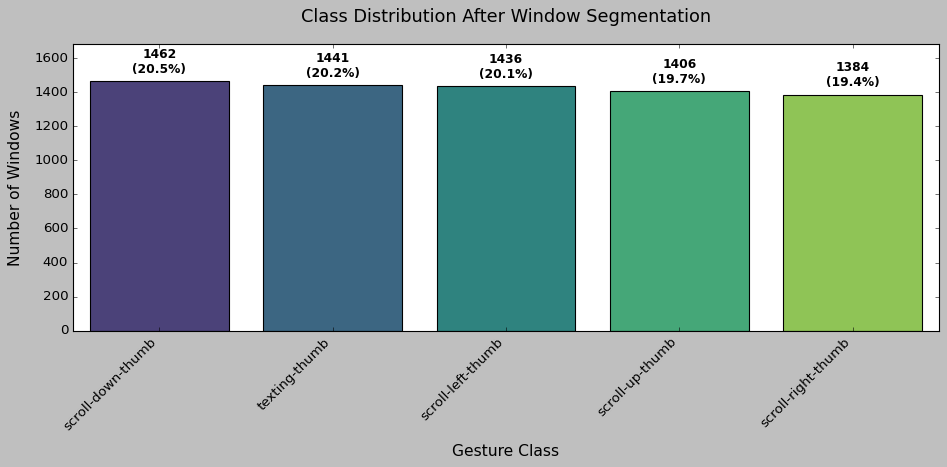

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert the list of labels to a Pandas Series for easy analysis
labels_series = pd.Series(all_labels)

# 2. Calculate raw counts and percentages
class_counts = labels_series.value_counts()
class_percentages = labels_series.value_counts(normalize=True) * 100

# 3. Print a clean summary table
imbalance_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages
})

print("Class Distribution After Window Segmentation:\n")
print(imbalance_df.round(2))
print("\n" + "="*60 + "\n")

# 4. Plot the distribution
plt.figure(figsize=(12, 6))

# Create the bar plot (sorted by default due to value_counts)
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')

plt.title("Class Distribution After Window Segmentation", fontsize=16, pad=20)
plt.xlabel("Gesture Class", fontsize=14, labelpad=10)
plt.ylabel("Number of Windows", fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)

# 5. Add the Count and Percentage text on top of each bar
for i, p in enumerate(ax.patches):
    height = p.get_height()
    percentage = class_percentages.iloc[i]
    
    # Format the text (e.g., "450\n(20.5%)")
    annotation_text = f'{int(height)}\n({percentage:.1f}%)'
    
    ax.annotate(annotation_text, 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

# Expand y-axis slightly to make room for the text annotations at the top
plt.ylim(0, class_counts.max() * 1.15)

# Adjust layout to prevent the rotated X-labels from getting cut off
plt.tight_layout()
plt.show()

## 7. Feature Engineering: Flattening & Encoding
For traditional ML classifiers (like Support Vector Machines or Random Forests) to process time-series data without internal recurrent layers, the 2D window matrices (Time Steps × Sensor Axes) must be flattened into a single 1D feature vector. String gesture labels are also encoded into numeric formats.

In [85]:
# ---------------------------------------------
# Window Flattening & Label Encoding
# ---------------------------------------------
from utils import encode_labels

print("Starting window flattening...")

# 1. Flatten the list of window DataFrames into a single 2D DataFrame (Samples x Features)
# Each window (e.g., 100 rows x 6 sensor axes) becomes one long row (e.g., 600 features)
flattened_df = flatten_instances_df(all_windows)

print(f"Shape of the flattened dataset (X): {flattened_df.shape}")

# 2. Assign the tracked string labels to a new target column 'y'
flattened_df['y'] = all_labels

# 3. Separate features (X) and target (y)
X = flattened_df.drop(columns=['y']).values
y_strings = flattened_df['y'].tolist()

# 4. Encode the string labels (e.g., 'scroll-up-thumb') into integers (e.g., 0, 1, 2...)
y_encoded = encode_labels(y_strings)

print("Flattening and encoding complete!")
print(f"X shape: {X.shape}")
print(f"y shape: {y_encoded.shape}")

# Optional: View the mapping of unique encoded classes
unique_classes = np.unique(y_encoded)
print(f"Unique encoded classes: {unique_classes}")

Starting window flattening...
Shape of the flattened dataset (X): (7129, 720)
Flattening and encoding complete!
X shape: (7129, 720)
y shape: (7129,)
Unique encoded classes: [0 1 2 3 4]


## 8. Train/Test Split & Feature Scaling
To strictly prevent **Data Leakage**, the dataset is split into Training and Testing sets *before* any scaling is applied. 

Because of the extreme outliers observed in the gyroscope data, a robust scaling method (e.g., `StandardScaler` or `RobustScaler`) is fitted exclusively on the Training set. The Test set is then transformed using these learned parameters, simulating completely unseen, real-world data.

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Splitting data into Train and Test sets...")

# --- 1. Train-Test Split ---
# We use stratify=y_strings to ensure the 80/20 ratio is perfectly balanced across all gesture classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y_strings, test_size=0.2, random_state=42, stratify=y_strings
)

# --- 2. Scale the Features (Preventing Data Leakage) ---
scaler = StandardScaler()
# FIT the scaler only on the training data to learn the mean and variance, then transform it
X_train_scaled = scaler.fit_transform(X_train)
# ONLY transform the test data using the rules learned from the training data
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Splitting data into Train and Test sets...
X_train shape: (5703, 720)
X_test shape: (1426, 720)


## 9. Dimensionality Reduction & Visualization (PCA)
Flattening the temporal windows results in a highly dimensional dataset (e.g., hundreds of features). We use Principal Component Analysis (PCA) strictly as an EDA tool here to reduce the data to 2D/3D space. By plotting both the Train and Test sets, we verify that they share the same underlying mathematical distribution, indicating the model should generalize well.

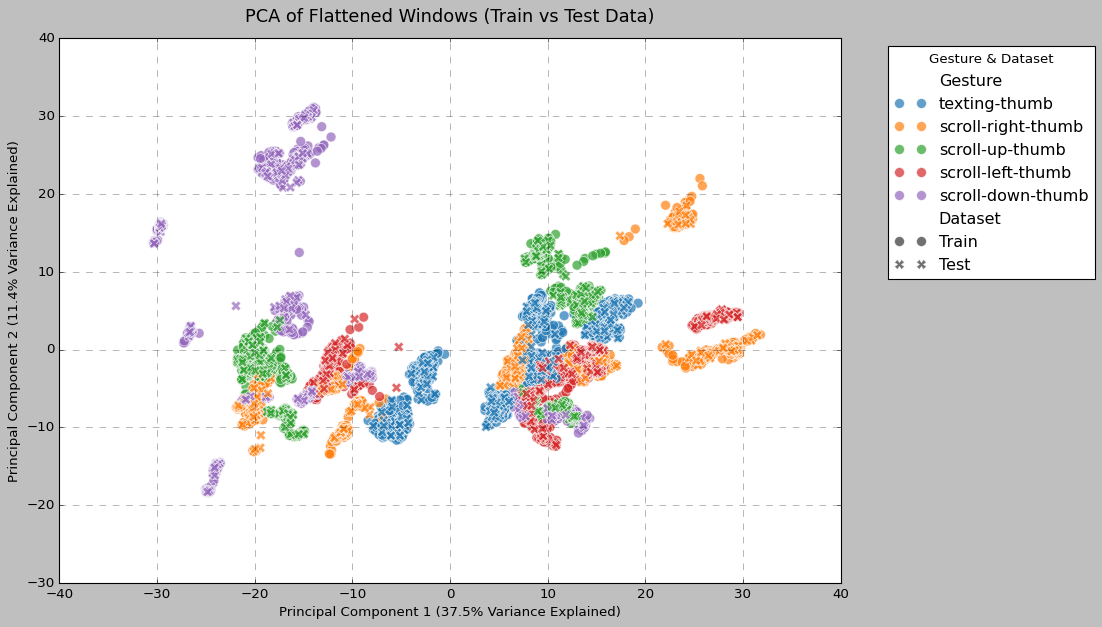

In [87]:
# --- 3. Fit PCA and Reduce to 2 Components ---
pca = PCA(n_components=2)
# FIT the PCA only on the scaled training data, then transform it
X_train_pca = pca.fit_transform(X_train_scaled)
# ONLY transform the test data into the principal components learned from the training data
X_test_pca = pca.transform(X_test_scaled)

# --- 4. Create DataFrames for Visualization ---
# Create Training DataFrame
df_train = pd.DataFrame(data=X_train_pca, columns=['PC1', 'PC2'])
df_train['Gesture'] = y_train
df_train['Dataset'] = 'Train'  # Tag it so we know it's training data

# Create Testing DataFrame
df_test = pd.DataFrame(data=X_test_pca, columns=['PC1', 'PC2'])
df_test['Gesture'] = y_test
df_test['Dataset'] = 'Test'    # Tag it so we know it's testing data

# Combine them for the Seaborn plot
pca_df = pd.concat([df_train, df_test], ignore_index=True)

# --- 5. Plot using Seaborn ---
plt.figure(figsize=(14, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Gesture',      # Color the dots by the Gesture Class
    style='Dataset',    # Differentiate Train (circles) vs Test (crosses)
    palette='tab10',    # Distinct colors for each class
    data=pca_df,
    alpha=0.7,
    s=80                # Slightly larger markers to see the shapes better
)

# Add informative titles and labels, showing the explained variance percentages
var_1 = pca.explained_variance_ratio_[0] * 100
var_2 = pca.explained_variance_ratio_[1] * 100

plt.title('PCA of Flattened Windows (Train vs Test Data)', fontsize=16, pad=15)
plt.xlabel(f'Principal Component 1 ({var_1:.1f}% Variance Explained)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_2:.1f}% Variance Explained)', fontsize=12)

# Move the legend outside the plot so it doesn't cover data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Gesture & Dataset')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Fitting PCA with 3 components...


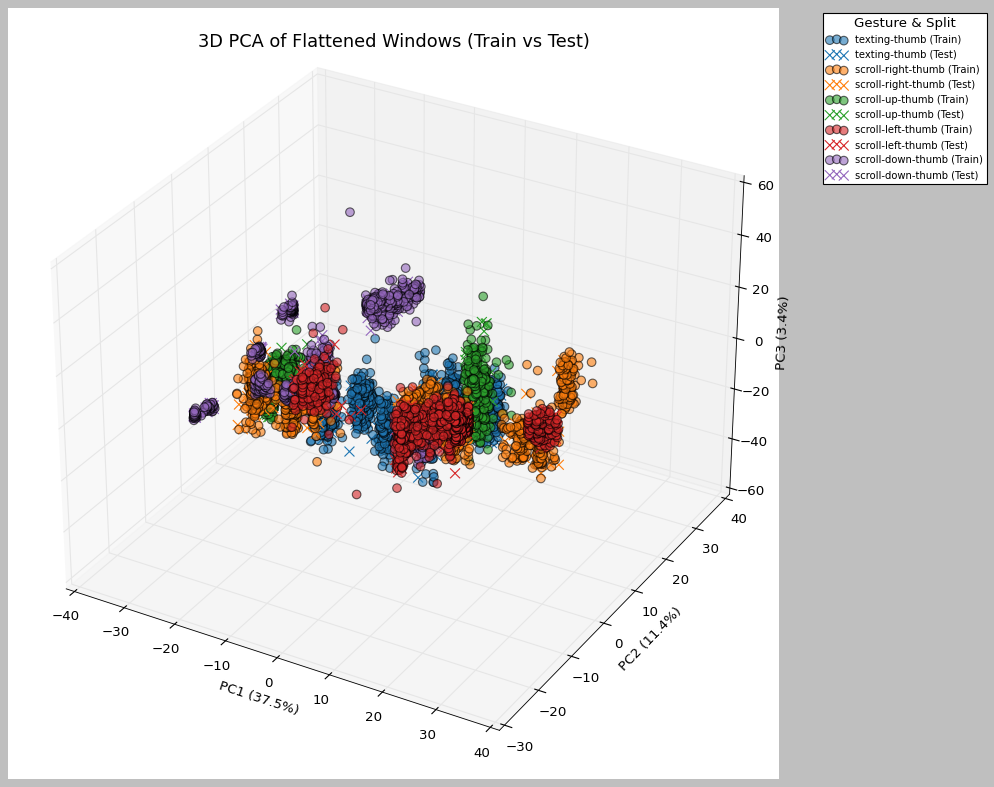

Total variance explained by 3 components: 52.27%


In [88]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

print("Fitting PCA with 3 components...")

# --- 1. Fit PCA and Reduce to 3 Components ---
pca_3d = PCA(n_components=3)

# Fit on training data, transform both
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)
X_test_pca_3d = pca_3d.transform(X_test_scaled)

# --- 2. Create DataFrames for Visualization ---
df_train_3d = pd.DataFrame(data=X_train_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_train_3d['Gesture'] = y_train
df_train_3d['Dataset'] = 'Train'

df_test_3d = pd.DataFrame(data=X_test_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_test_3d['Gesture'] = y_test
df_test_3d['Dataset'] = 'Test'

# Combine into one DataFrame
pca_df_3d = pd.concat([df_train_3d, df_test_3d], ignore_index=True)

# --- 3. Plotting in 3D ---
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Define a color map so each gesture gets a distinct color
unique_gestures = pca_df_3d['Gesture'].unique()
colors = plt.cm.tab10.colors[:len(unique_gestures)]
color_map = dict(zip(unique_gestures, colors))

# Loop through the data to plot Train (circles) and Test (crosses)
for gesture in unique_gestures:
    # Plot Train data
    train_subset = pca_df_3d[(pca_df_3d['Gesture'] == gesture) & (pca_df_3d['Dataset'] == 'Train')]
    ax.scatter(train_subset['PC1'], train_subset['PC2'], train_subset['PC3'],
               c=[color_map[gesture]], marker='o', s=60, alpha=0.6, label=f"{gesture} (Train)")

    # Plot Test data
    test_subset = pca_df_3d[(pca_df_3d['Gesture'] == gesture) & (pca_df_3d['Dataset'] == 'Test')]
    ax.scatter(test_subset['PC1'], test_subset['PC2'], test_subset['PC3'],
               c=[color_map[gesture]], marker='x', s=80, alpha=1.0, label=f"{gesture} (Test)")

# --- 4. Add Labels and Titles ---
var_1, var_2, var_3 = pca_3d.explained_variance_ratio_ * 100

ax.set_title('3D PCA of Flattened Windows (Train vs Test)', fontsize=16, pad=20)
ax.set_xlabel(f'PC1 ({var_1:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_2:.1f}%)', fontsize=12)
ax.set_zlabel(f'PC3 ({var_3:.1f}%)', fontsize=12)

# Move the legend outside the plot
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Gesture & Split", fontsize=9)

plt.tight_layout()
plt.show()

# Print the total variance captured by 3 components
total_variance = var_1 + var_2 + var_3
print(f"Total variance explained by 3 components: {total_variance:.2f}%")

## 10. Model Training & Hyperparameter Tuning
With the data fully processed, flattened, and scaled, we train our primary classifier. We utilize cross-validation (e.g., `GridSearchCV`) on the Training set to find the optimal hyperparameters. 
*(Note: If utilizing an SVC, we may optionally pipe the data through PCA to mitigate the "curse of dimensionality" and reduce computation time).*

## 11. Final Model Evaluation
We evaluate the optimized model on our unseen Test set. Using accuracy metrics and a Confusion Matrix, we analyze which gestures the model successfully learned and which ones it mathematically confused due to similar physical trajectories.

## Data Processing

## Train/Test split

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42)

## Scaling

In [91]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Classifier - Statistical Learning

### Apply simple classifier

In [92]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

### Evaluate simple classifier

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [94]:
from sklearn.metrics import classification_report

### Apply optimization with Grid Search and/or Cross-validation

In [95]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Evaluate optimized classifier